# DSPy Starship: The Take-Home Notebook

**From Crop Duster to Starship: Let DSPy Tune Your Prompts in Plain Python**

PyHou, July 21 2026. Ahliana Byrd.

This is the annotated version of the talk. It's the same working program you saw on stage, with every step explained so you can learn DSPy from this file alone. Run it top to bottom and read the notes as you go.

## The one idea

Most people improve a language model by editing the prompt by hand. That's the crop duster: low altitude, exhausting, and every new model release wipes out your tuning. DSPy is the starship. You **declare** what you want, you **compose** how the model is asked, and you let an optimizer **tune** the prompt for you. You stop writing prompts and start writing programs.

## Three primitives, in order

1. **Declare** a signature: the inputs and outputs, nothing else.
2. **Compose** with a module: `Predict`, `ChainOfThought`, or `ReAct`, which decide how the model is asked.
3. **Optimize**: hand DSPy a few examples and a metric, and it writes a better prompt than you would by hand.

## The x-ray glasses

`dspy.inspect_history(n=1)` is the running metaphor of this talk. Every time you call it, you see the exact prompt DSPy sent to the model. You never write that prompt; the library writes it from your signature. Watch for the glasses going on throughout the notebook.

## How this notebook is marked

- Normal cells are the live demo. Run them in order.
- Cells that begin with **TAKE-HOME NOTE** are extra explanation for self-study. Skip them when presenting.
- Code cells that start with **TAKE-HOME EXERCISE** are commented out on purpose so a straight run never touches them. Uncomment them at home to experiment.

## Step 0: Pick your model (the only choice you make)

DSPy talks to language models through a universal adapter called LiteLLM. The provider lives entirely in one string, like `"anthropic/claude-haiku-4-5-20251001"` or `"openai/gpt-4o-mini"`. Nothing else in this notebook, no signature, no module, no optimizer, cares which model sits behind it. That portability is the whole point of the talk.

Your only setup is **one** API key. Copy `.env.example` to `.env` and add whichever key you have:

```
ANTHROPIC_API_KEY=sk-ant-...
```
or
```
OPENAI_API_KEY=sk-...
```

The next cell detects which key is present and selects a fast model and a bigger model to match. If you have both keys, Anthropic is used by default.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("ANTHROPIC_API_KEY"):
    PROVIDER = "anthropic"
    FAST_MODEL = "anthropic/claude-haiku-4-5-20251001"
    BIG_MODEL = "anthropic/claude-sonnet-4-6"
    FAST_LABEL, BIG_LABEL = "Claude Haiku 4.5", "Claude Sonnet 4.6"
elif os.environ.get("OPENAI_API_KEY"):
    PROVIDER = "openai"
    FAST_MODEL = "openai/gpt-4o-mini"
    BIG_MODEL = "openai/gpt-4o"
    FAST_LABEL, BIG_LABEL = "GPT-4o mini", "GPT-4o"
else:
    raise RuntimeError(
        "No API key found. Add ANTHROPIC_API_KEY or OPENAI_API_KEY to your .env file."
    )

print(f"Provider: {PROVIDER}")
print(f"Fast model: {FAST_LABEL}  ({FAST_MODEL})")
print(f"Bigger model, used once in the model-swap demo: {BIG_LABEL}  ({BIG_MODEL})")

Provider: anthropic
Fast model: Claude Haiku 4.5  (anthropic/claude-haiku-4-5-20251001)
Bigger model, used once in the model-swap demo: Claude Sonnet 4.6  (anthropic/claude-sonnet-4-6)


> **TAKE-HOME NOTE (for self-study, skip this when you present live).**

The whole trick is that `FAST_MODEL` and `BIG_MODEL` are just strings. To run on a local model with Ollama you'd write `"ollama/llama3"`. For Gemini you'd write `"gemini/gemini-1.5-pro"`. LiteLLM handles the differences in API shape for you, and you'll never change a signature, a module, or an optimizer to switch models. Keep that in mind when you reach the model-swap demo later.

## Cell 1: Connect DSPy to your model

`dspy.LM(...)` builds a handle to a language model. `dspy.configure(lm=...)` makes that model the default for every DSPy call below, so you don't pass it around by hand. `max_tokens=800` caps the length of each response, and `temperature=0.0` makes the demo deterministic: same inputs, same outputs, which is exactly what you want on stage and when comparing accuracy numbers.

If `Starship online.` prints, you are connected and ready.

In [2]:
import dspy

lm = dspy.LM(FAST_MODEL, max_tokens=800, temperature=0.0)
dspy.configure(lm=lm)
print(f"Starship online. Flying {FAST_LABEL}.")

Starship online. Flying Claude Haiku 4.5.


## DECLARE

### Cell 2: Your first signature

A **signature** is a specification of a task: what goes in, what comes out. The string `"text -> sentiment: str"` says "take a field called `text`, produce a field called `sentiment` that is a string." The part before the arrow is inputs, the part after is outputs.

You did not write a prompt. You described the shape of the task, and `dspy.Predict` turns that description into a runnable program. When you call it, DSPy builds a real prompt behind the scenes, sends it to the model, and parses the answer back into the `sentiment` field.

In [3]:
classify = dspy.Predict("text -> sentiment: str")
result = classify(text="The launch was successful and the crew is in great spirits.")
print(result.sentiment)

positive


### Cell 3: X-ray glasses, moment 1

Here's the reveal. `dspy.inspect_history(n=1)` prints the last thing DSPy sent to the model. Look at the output: there's a full prompt with a system message, a description of the input and output fields, and formatting instructions telling the model how to structure its answer.

You wrote none of that. The library generated the entire prompt from your five-character signature. This is the paradigm shift in one screen: **you edit signatures, you never edit prompts.**

In [4]:
dspy.inspect_history(n=1)





[2026-07-16T00:36:37.503966]

System message:

Your input fields are:
1. `text` (str):
Your output fields are:
1. `sentiment` (str):
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## text ## ]]
{text}

[[ ## sentiment ## ]]
{sentiment}

[[ ## completed ## ]]
In adhering to this structure, your objective is: 
        Given the fields `text`, produce the fields `sentiment`.


User message:

[[ ## text ## ]]
The launch was successful and the crew is in great spirits.

Respond with the corresponding output fields, starting with the field `[[ ## sentiment ## ]]`, and then ending with the marker for `[[ ## completed ## ]]`.


Response:

[[ ## sentiment ## ]]
positive

[[ ## completed ## ]]







> **TAKE-HOME NOTE (for self-study, skip this when you present live).**

How to read the x-ray output. DSPy prints the messages it sent as a conversation. You'll usually see:

- A **system message** that states the task and lists each input and output field with its name and any description.
- A **user message** that contains your actual input values.
- Formatting markers such as `[[ ## sentiment ## ]]` that tell the model exactly where to put each output. DSPy uses those markers to parse the reply back into fields.

When something goes wrong later, say an output field comes back empty or malformed, the first thing to do is put the glasses on and read the prompt DSPy actually sent. The problem is almost always obvious once you can see it.

### Cell 4: Class-form signatures

The string form is great for quick work. For real programs you write the signature as a class, which gives you typed fields, human-readable descriptions, and a docstring that becomes part of the instruction to the model. Everything else works exactly the same.

Notice that `severity` has a description constraining it to three values, and `summary` asks for one sentence. Those descriptions flow straight into the generated prompt.

In [5]:
class TransmissionReport(dspy.Signature):
    """Classify a transmission from a spacecraft."""
    transmission: str = dspy.InputField()
    severity: str = dspy.OutputField(desc="One of: nominal, advisory, urgent")
    summary: str = dspy.OutputField(desc="One sentence summary")

report = dspy.Predict(TransmissionReport)
out = report(transmission="Houston, we have a problem. Main bus B undervolt.")
print(f"Severity: {out.severity}")
print(f"Summary: {out.summary}")

Severity: urgent
Summary: Main bus B is experiencing an undervoltage condition, indicating a critical power system failure requiring immediate attention.


> **TAKE-HOME NOTE (for self-study, skip this when you present live).**

Try this at home: add a third output field to `TransmissionReport`, for example `recommended_action: str = dspy.OutputField(desc="What the crew should do next")`, then rerun. You didn't touch a prompt, yet the model now returns a new structured field. That's what declaring buys you: changing the interface is a one-line edit.

In [6]:
# ===== TAKE-HOME EXERCISE. Not run live. Uncomment to try it at home. =====
# class TransmissionReportPlus(dspy.Signature):
#     """Classify a transmission from a spacecraft and recommend an action."""
#     transmission: str = dspy.InputField()
#     severity: str = dspy.OutputField(desc="One of: nominal, advisory, urgent")
#     summary: str = dspy.OutputField(desc="One sentence summary")
#     recommended_action: str = dspy.OutputField(desc="What the crew should do next")
#
# report_plus = dspy.Predict(TransmissionReportPlus)
# out2 = report_plus(transmission="Coolant loop temperature trending upward slowly.")
# print(out2.severity, "|", out2.summary, "|", out2.recommended_action)

### Cell 5: A signature does not police your intent

DSPy doesn't judge what you ask for. It compiles your signature to a prompt and asks the model, even when the task makes no sense, so here we ask the model to pick a stock from a vibe. The model gamely tries. Weird in, weird out. The lesson underneath the joke is that the quality of your outputs depends on the quality of your task design, not on clever prompt wording.

In [7]:
vibes = dspy.Predict("vibes -> stock_pick: str, confidence: float")
print(vibes(vibes="kind of a mercury retrograde tuesday energy"))

Prediction(
    stock_pick='NVDA',
    confidence=0.23
)


### Cell 6: The partner activity (typed live on stage)

During the talk, an attendee's own signature gets typed into this cell and run live. The example below extracts action items from a meeting transcript, and it shows the shape: declare the fields, pick `Predict`, call it.

At home, replace the signature with a task from your own work. That's the fastest way to feel how little ceremony DSPy needs.

In [8]:
class AttendeeMission(dspy.Signature):
    """Extract action items from a meeting transcript."""
    transcript: str = dspy.InputField()
    action_items: str = dspy.OutputField(desc="Newline-separated list of action items")

demo = dspy.Predict(AttendeeMission)
result = demo(transcript="Sarah will draft the proposal by Friday. Mike will review the budget by Wednesday. Everyone needs to update their availability for next week.")
print(result.action_items)

Sarah: Draft the proposal by Friday
Mike: Review the budget by Wednesday
Everyone: Update availability for next week


## COMPOSE

### Cell 7: Modules decide *how* the model is asked

A signature says **what** the task is. A **module** says **how** to run it. The same signature behaves differently depending on the module you wrap it in:

- `dspy.Predict` just asks the model directly.
- `dspy.ChainOfThought` tells the model to reason step by step first, then answer. It adds a `reasoning` field automatically.
- `dspy.ReAct` lets the model call tools you provide, in a loop.

Below, the same `ExplainCode` signature runs through `Predict` and then `ChainOfThought`. The reasoning field appears in the second one because you swapped a single word, and the glasses at the bottom show you what `ChainOfThought` added to the prompt.

In [9]:
class ExplainCode(dspy.Signature):
    """Explain what this Python code does in plain English."""
    code: str = dspy.InputField()
    explanation: str = dspy.OutputField()

snippet = "def fib(n):\n    return n if n <= 1 else fib(n-1) + fib(n-2)"

print("Predict says:")
print(dspy.Predict(ExplainCode)(code=snippet).explanation)
print("\nChainOfThought says:")
result = dspy.ChainOfThought(ExplainCode)(code=snippet)
print(f"Reasoning: {result.reasoning}\n")
print(f"Explanation: {result.explanation}")

# X-RAY GLASSES MOMENT 2: peek at both prompts
print("\n--- Both prompts DSPy sent ---")
dspy.inspect_history(n=2)

Predict says:
This function calculates the nth number in the Fibonacci sequence using recursion.

Here's how it works:
- It takes a single parameter `n`, which represents the position in the Fibonacci sequence
- If `n` is 0 or 1, it returns `n` directly (base cases: fib(0)=0, fib(1)=1)
- For any `n` greater than 1, it recursively calls itself twice: once with `n-1` and once with `n-2`, then adds the results together
- This follows the Fibonacci pattern where each number is the sum of the two preceding numbers (0, 1, 1, 2, 3, 5, 8, 13, ...)

For example, `fib(5)` would return 5, since the sequence goes: 0, 1, 1, 2, 3, 5.

Note: While this solution is elegant and mathematically straightforward, it's inefficient for large values of `n` because it recalculates the same values many times.

ChainOfThought says:
Reasoning: This is a recursive function that implements the Fibonacci sequence. The function takes a single parameter `n` and uses a conditional expression to determine the output. Fo

> **TAKE-HOME NOTE (for self-study, skip this when you present live).**

Look closely at the two prompts the glasses printed. The `ChainOfThought` version contains an extra instruction, roughly "think step by step and show your reasoning," plus a `reasoning` output field ahead of the answer. You didn't write that instruction; the module injected it. This is why modules matter. They're reusable strategies for asking, and you get them by changing one word rather than rewriting a prompt.

### Cell 8: Modules compose into real tools

Put a signature and a module together and you have a working tool. Here's a code reviewer: give it Python, get back a quality score, a list of issues, and an improved version, all in one call. This is the entire program. There's no prompt engineering and no output parsing by hand, because DSPy handles the structure.

In [10]:
class CodeReviewSig(dspy.Signature):
    """Review Python code and return structured findings."""
    code: str = dspy.InputField()
    quality: int = dspy.OutputField(desc="Quality score from 1 to 10")
    issues: str = dspy.OutputField(desc="Newline-separated list of specific issues")
    improved: str = dspy.OutputField(desc="The code rewritten with the issues fixed")

reviewer = dspy.ChainOfThought(CodeReviewSig)

code_to_review = """
def calculate_total(items):
    total = 0
    for item in items:
        total = total + item.price
    return total
"""

result = reviewer(code=code_to_review)
print(f"Quality: {result.quality}/10")
print(f"Issues:\n{result.issues}")
print(f"\nImproved:\n{result.improved}")

Quality: 6/10
Issues:
Missing docstring explaining function purpose, parameters, and return value
No type hints for better code clarity and IDE support
No input validation or error handling for edge cases
Verbose loop could be replaced with sum() and a generator expression
No handling for items without a price attribute
No handling for None or empty input
Could raise AttributeError if item lacks price attribute without clear error message

Improved:
def calculate_total(items: list) -> float:
    """
    Calculate the total price of all items.
    
    Args:
        items: A list of objects with a 'price' attribute
        
    Returns:
        The sum of all item prices as a float
        
    Raises:
        TypeError: If items is not iterable
        AttributeError: If any item lacks a 'price' attribute
    """
    if not items:
        return 0.0
    
    return sum(item.price for item in items)


### Cell 9: Swap models in one line

This is the portability payoff. The same `reviewer` program runs on a bigger model with no other change. The signature doesn't change, and neither does the module. You pass a different model into a `dspy.context` block and everything downstream uses it.

`dspy.context(lm=...)` temporarily overrides the default model for the calls inside the `with` block, then restores it. On an Anthropic key this is Haiku to Sonnet; on an OpenAI key it's `gpt-4o-mini` to `gpt-4o`. Same code either way.

In [11]:
big = dspy.LM(BIG_MODEL, max_tokens=1000)
with dspy.context(lm=big):
    big_result = reviewer(code=code_to_review)

print(f"{FAST_LABEL} said:")
print(result.improved)
print("\n---\n")
print(f"{BIG_LABEL} said:")
print(big_result.improved)

Claude Haiku 4.5 said:
def calculate_total(items: list) -> float:
    """
    Calculate the total price of all items.
    
    Args:
        items: A list of objects with a 'price' attribute
        
    Returns:
        The sum of all item prices as a float
        
    Raises:
        TypeError: If items is not iterable
        AttributeError: If any item lacks a 'price' attribute
    """
    if not items:
        return 0.0
    
    return sum(item.price for item in items)

---

Claude Sonnet 4.6 said:
from typing import Protocol, Sequence


class Priceable(Protocol):
    price: float


def calculate_total(items: Sequence[Priceable]) -> float:
    """Calculate the total price of all items.

    Args:
        items: A sequence of objects with a `price` attribute.

    Returns:
        The sum of all item prices as a float.

    Raises:
        TypeError: If items is None or contains objects without a price attribute.
    """
    if items is None:
        raise TypeError("items cannot

> **TAKE-HOME NOTE (for self-study, skip this when you present live).**

This is the moment to internalize the crop-duster-to-starship metaphor. In the hand-tuned world, moving to a new model means re-testing and often rewriting your prompt, because prompts are brittle and model-specific. In DSPy, the model is a parameter. You change the string. When a better or cheaper model ships next month, you re-point one line and, if you want, re-run the optimizer you're about to meet. Your program does not change.

## OPTIMIZE

### Cell 10: The task, the data, and the baseline

This is the payoff third. The task: classify a spacecraft transmission by urgency, into `routine`, `attention`, or `urgent`.

There's a catch, and it's the whole point. This team uses a specific convention: a **confirmed** threat is `urgent`, but a **suspected or unconfirmed** hazard is only `attention`, because the first move is to investigate, not to scramble. That isn't something a model can guess from common sense, since a safety-first human would escalate anything that smells like danger. The right answer lives in the labeled data rather than in general knowledge, which is exactly the situation where optimization earns its keep.

To optimize anything you need three things:

1. **Training examples**: a handful of inputs paired with the right output. `dspy.Example(...).with_inputs("transmission")` marks which field is the input; the rest is the label.
2. **A held-out test set**: examples the optimizer never sees, used to measure honestly.
3. **A metric**: a function that scores a prediction. Here `match` returns `True` when the predicted urgency equals the expected one.

The **baseline** is plain `Predict` with no examples and no optimization. It's the "before" picture. The glasses show how bare that baseline prompt is, and then we score it on all ten test transmissions. On Claude Haiku 4.5 it lands at 60%: common sense carries the confirmed threats and the routine chatter, then stumbles on the convention cases. Remember that number. It's the bar for both hand-tuning and optimization.

In [12]:
class ClassifyTransmission(dspy.Signature):
    """Classify a spacecraft transmission by urgency."""
    transmission: str = dspy.InputField()
    urgency: str = dspy.OutputField(desc="One of: routine, attention, urgent")

# Training set for the optimizer. The convention is not about scary keywords,
# it is about CONFIRMATION. A confirmed threat is urgent. A suspected or
# unconfirmed anomaly, or one still under investigation, is attention. Normal
# operations, drills, and completed tests are routine. A model cannot guess
# this convention from world knowledge, it has to learn it from these labels.
train = [
    dspy.Example(transmission="Suspected coolant leak, still confirming whether it is real.",
                 urgency="attention").with_inputs("transmission"),
    dspy.Example(transmission="Confirmed cabin depressurization, crew on emergency oxygen.",
                 urgency="urgent").with_inputs("transmission"),
    dspy.Example(transmission="Scheduled fire drill completed, all crew accounted for.",
                 urgency="routine").with_inputs("transmission"),
    dspy.Example(transmission="Unidentified vibration of unknown origin, investigating.",
                 urgency="attention").with_inputs("transmission"),
    dspy.Example(transmission="Main bus B undervolt confirmed, switching to backup now.",
                 urgency="urgent").with_inputs("transmission"),
    dspy.Example(transmission="Morning status check, all systems nominal.",
                 urgency="routine").with_inputs("transmission"),
    dspy.Example(transmission="Possible sensor fault causing erratic temperature readings, assessing.",
                 urgency="attention").with_inputs("transmission"),
    dspy.Example(transmission="Confirmed hull breach in module three, sealing bulkheads now.",
                 urgency="urgent").with_inputs("transmission"),
    dspy.Example(transmission="Radiation monitor calibration finished, readings as expected.",
                 urgency="routine").with_inputs("transmission"),
    dspy.Example(transmission="Intermittent alarm with no confirmed cause, monitoring.",
                 urgency="attention").with_inputs("transmission"),
    dspy.Example(transmission="Evening meal service proceeding on schedule.",
                 urgency="routine").with_inputs("transmission"),
    dspy.Example(transmission="Fuel pressure trending low but still within limits, watching.",
                 urgency="attention").with_inputs("transmission"),
]

# Held-out test set. The traps are the UNCONFIRMED hazards: a smoke detector
# that might be faulty, a possible leak, a suspected impact. The true label is
# attention (investigate first), but a safety-first prompt escalates them all
# to urgent. Confirmed threats and normal operations are the easy cases.
test = [
    dspy.Example(transmission="Smoke detector triggered; verifying whether it is a real fire or a faulty unit.",
                 urgency="attention").with_inputs("transmission"),
    dspy.Example(transmission="Confirmed reactor coolant leak, sealing the aft compartment now.",
                 urgency="urgent").with_inputs("transmission"),
    dspy.Example(transmission="Possible fuel leak on one sensor; a second sensor reads normal.",
                 urgency="attention").with_inputs("transmission"),
    dspy.Example(transmission="Morning coffee service commencing on the flight deck.",
                 urgency="routine").with_inputs("transmission"),
    dspy.Example(transmission="Suspected micro-meteoroid impact; checking whether the hull is compromised.",
                 urgency="attention").with_inputs("transmission"),
    dspy.Example(transmission="Confirmed loss of cabin pressure, don your masks now.",
                 urgency="urgent").with_inputs("transmission"),
    dspy.Example(transmission="Unconfirmed power dip reading; may be an instrument glitch.",
                 urgency="attention").with_inputs("transmission"),
    dspy.Example(transmission="Gyro reading drifting slightly, still within limits.",
                 urgency="attention").with_inputs("transmission"),
    dspy.Example(transmission="Battery fault confirmed, power dropping to critical, respond now.",
                 urgency="urgent").with_inputs("transmission"),
    dspy.Example(transmission="Cargo inventory audit finished ahead of schedule.",
                 urgency="routine").with_inputs("transmission"),
]

def match(example, pred, trace=None):
    return example.urgency.strip().lower() == pred.urgency.strip().lower()

def measure_accuracy(program, examples, label):
    correct = 0
    misses = []
    for ex in examples:
        pred = program(transmission=ex.transmission)
        if match(ex, pred):
            correct += 1
        else:
            misses.append((ex.urgency, pred.urgency.strip().lower(), ex.transmission))
    accuracy = correct / len(examples)
    print(f"{label}: {correct}/{len(examples)} correct ({accuracy*100:.0f}%)")
    for gold, got, text in misses:
        print(f"  MISS: expected {gold}, got {got}  |  {text[:58]}")
    if not misses:
        print("  No misses.")
    return accuracy

# Baseline: no optimization, no examples, just the signature
baseline = dspy.Predict(ClassifyTransmission)
print("Baseline test case:", baseline(transmission="Cabin fire, crew evacuating.").urgency)
print("\n--- X-RAY GLASSES MOMENT 3: baseline prompt ---")
dspy.inspect_history(n=1)

print("\nNow score the bare baseline on all 10 test transmissions:")
baseline_accuracy = measure_accuracy(baseline, test, "Plain Predict baseline")

Baseline test case:

 urgent

--- X-RAY GLASSES MOMENT 3: baseline prompt ---




[2026-07-16T00:36:37.837033]

System message:

Your input fields are:
1. `transmission` (str):
Your output fields are:
1. `urgency` (str): One of: routine, attention, urgent
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## transmission ## ]]
{transmission}

[[ ## urgency ## ]]
{urgency}

[[ ## completed ## ]]
In adhering to this structure, your objective is: 
        Classify a spacecraft transmission by urgency.


User message:

[[ ## transmission ## ]]
Cabin fire, crew evacuating.

Respond with the corresponding output fields, starting with the field `[[ ## urgency ## ]]`, and then ending with the marker for `[[ ## completed ## ]]`.


Response:

[[ ## urgency ## ]]
urgent

[[ ## completed ## ]]






Now score the bare baseline on all 10 test transmissions:


Plain Predict baseline: 6/10 correct (60%)
  MISS: expected attention, got urgent  |  Smoke detector triggered; verifying whether it is a real f
  MISS: expected attention, got urgent  |  Suspected micro-meteoroid impact; checking whether the hul
  MISS: expected attention, got routine  |  Unconfirmed power dip reading; may be an instrument glitch
  MISS: expected attention, got routine  |  Gyro reading drifting slightly, still within limits.


### Cell 11: The hand-tuned prompt (the crop duster)

This is what prompt engineering usually looks like. Below is a prompt written by hand: a role, category definitions, a strict safety policy, few-shot examples, and format instructions. Every trick in the book, and it's a completely reasonable, safety-first prompt.

Watch safety policy rule 2: "If a hazard is not yet confirmed, treat it as URGENT anyway." That's a sensible instinct for a flight controller, and it's exactly the trap. Our team's real convention is that an *unconfirmed* hazard is `attention` (investigate first), and only a *confirmed* threat is `urgent`. The prompt's author guessed a policy that doesn't match the data. A prompt encodes what you guessed. It cannot know a convention you never wrote down.

`HandTunedProgram` wraps that prompt so it has the same calling interface as a DSPy program, which lets us score it with the exact same `measure_accuracy` function on the exact same test set. Then we read its accuracy. This is the number DSPy has to beat.

In [13]:
HAND_TUNED_PROMPT = """You are an expert flight controller with 20 years of experience \
classifying spacecraft transmissions. Categorize each transmission by urgency.

CATEGORIES:
- routine: normal operations, scheduled activities, no anomalies
- attention: a minor anomaly that is clearly under control
- urgent: any threat to crew or vehicle

SAFETY POLICY (this is critical, follow it strictly):
1. Any mention of fire, smoke, leak, pressure loss, power loss, or radiation is URGENT.
2. If a hazard is not yet confirmed, treat it as URGENT anyway. Never wait for confirmation.
3. When in doubt, escalate. It is always safer to over-report.

EXAMPLES:
- "Cabin humidity slightly elevated, within acceptable range." -> attention
- "Confirmed hull breach, sealing bulkheads now." -> urgent
- "Daily science experiment completed on schedule." -> routine

Reply with EXACTLY one word: routine, attention, or urgent. No punctuation, no explanation.

Transmission: {transmission}

Urgency:"""

# Wrap the hand-tuned prompt in a callable program with the same interface
class HandTunedProgram:
    def __call__(self, transmission):
        from types import SimpleNamespace
        # Send the hand-tuned prompt directly to the LM
        response = lm(prompt=HAND_TUNED_PROMPT.format(transmission=transmission))
        # LM returns a list of strings, take the first, strip
        raw = response[0].strip().lower()
        # Normalize: sometimes the model adds a period or extra words
        for word in ["routine", "attention", "urgent"]:
            if word in raw:
                return SimpleNamespace(urgency=word)
        return SimpleNamespace(urgency=raw)

hand_tuned = HandTunedProgram()

print("Running the hand-tuned prompt on 10 test transmissions...")
print()
hand_tuned_accuracy = measure_accuracy(hand_tuned, test, "Hand-tuned prompt")
print()
print("--- X-RAY GLASSES MOMENT 4: the last hand-tuned prompt sent ---")
dspy.inspect_history(n=1)

Running the hand-tuned prompt on 10 test transmissions...

Hand-tuned prompt: 6/10 correct (60%)
  MISS: expected attention, got urgent  |  Smoke detector triggered; verifying whether it is a real f
  MISS: expected attention, got urgent  |  Possible fuel leak on one sensor; a second sensor reads no
  MISS: expected attention, got urgent  |  Suspected micro-meteoroid impact; checking whether the hul
  MISS: expected attention, got urgent  |  Unconfirmed power dip reading; may be an instrument glitch

--- X-RAY GLASSES MOMENT 4: the last hand-tuned prompt sent ---




[2026-07-16T00:36:38.053440]

User message:

You are an expert flight controller with 20 years of experience classifying spacecraft transmissions. Categorize each transmission by urgency.

CATEGORIES:
- routine: normal operations, scheduled activities, no anomalies
- attention: a minor anomaly that is clearly under control
- urgent: any threat to crew or vehicle

SAFETY POLICY (this is critical, follow it strictly):
1. Any

### Cell 12: Beat it, live (the starship)

Now DSPy. Zero hours of manual prompt writing. We hand `BootstrapFewShot` the training examples and the `match` metric, and it does the rest.

Here's what the optimizer actually does: it runs your baseline program on each training example, keeps the cases the program already gets right, and packs those correct input-output pairs into the prompt as demonstrations. In effect it's picking the best few-shot examples for you, guided by your metric. `max_bootstrapped_demos=4` caps the bootstrapped demonstrations at four.

The reason this beats the hand-tuned prompt: the training examples encode the real convention (confirmed threat is urgent, unconfirmed hazard is attention), so the demonstrations teach the model exactly what the safety-first prompt got wrong. You did not write better rules. You let labeled examples define the boundary.

Then we score the optimized program on the same 10 test examples and compare. The glasses at the end reveal the demonstrations DSPy chose and wrote into the prompt.

In [14]:
from dspy.teleprompt import BootstrapFewShot
import time

start = time.time()
optimizer = BootstrapFewShot(metric=match, max_bootstrapped_demos=4)
optimized = optimizer.compile(student=dspy.Predict(ClassifyTransmission), trainset=train)
elapsed = time.time() - start
print(f"BootstrapFewShot compiled in {elapsed:.1f} seconds")
print()

# Score on the same 10 test examples
optimized_accuracy = measure_accuracy(optimized, test, "DSPy BootstrapFewShot")

print()
print(f"Plain Predict baseline:  {baseline_accuracy*100:.0f}%")
print(f"Hand-tuned prompt:       {hand_tuned_accuracy*100:.0f}%")
print(f"DSPy BootstrapFewShot:   {optimized_accuracy*100:.0f}%")
print()
if optimized_accuracy > hand_tuned_accuracy:
    print("STARSHIP WINS.")
elif optimized_accuracy == hand_tuned_accuracy:
    print("STARSHIP TIES. Faster to build. Portable across models.")
else:
    print("Hand-tuned won this round. Try MIPROv2 below.")

print()
print("--- X-RAY GLASSES MOMENT 5: what BootstrapFewShot wrote ---")
dspy.inspect_history(n=1)

print(f"\nBootstrapFewShot attached {len(optimized.demos)} demonstrations, picked from the training set by the metric.")

  0%|          | 0/12 [00:00<?, ?it/s]

 33%|███▎      | 4/12 [00:00<00:00, 40.99it/s]

Bootstrapped 4 full traces after 4 examples for up to 1 rounds, amounting to 4 attempts.
BootstrapFewShot compiled in 0.1 seconds



DSPy BootstrapFewShot: 9/10 correct (90%)
  MISS: expected attention, got urgent  |  Smoke detector triggered; verifying whether it is a real f

Plain Predict baseline:  60%
Hand-tuned prompt:       60%
DSPy BootstrapFewShot:   90%

STARSHIP WINS.

--- X-RAY GLASSES MOMENT 5: what BootstrapFewShot wrote ---




[2026-07-16T00:36:38.417940]

System message:

Your input fields are:
1. `transmission` (str):
Your output fields are:
1. `urgency` (str): One of: routine, attention, urgent
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## transmission ## ]]
{transmission}

[[ ## urgency ## ]]
{urgency}

[[ ## completed ## ]]
In adhering to this structure, your objective is: 
        Classify a spacecraft transmission by urgency.


User message:

[[ ## transmission ## ]]
Suspected coolant leak, still confirming whether it is real.


Assistant message:

[[ ## urgency ## ]]
attention

[[ ## completed ## ]]


User message:

[[ ## transmission #

### The MIPROv2 reveal

`BootstrapFewShot` only picks demonstrations. `MIPROv2` goes further: it uses Bayesian search to propose and test different **instructions** as well as different **demonstration sets**, keeping the combinations that score best on your metric. It also wants more data than a live demo carries, so it was compiled ahead of time (a few minutes) on a larger 40-example training set plus a separate 20-example validation split, and saved to `miprov2_artifact.json`. The compile recipe is `scripts/run_miprov2.py`. The held-out test set below is the same 10 examples as everything else, and neither optimizer ever saw it.

Here's the payoff. On this task MIPROv2 doesn't just pick demos, it **writes the convention out as an instruction**. It reverse-engineered from the data that "Confirmed" plus an active crisis is urgent, that hedging words like "suspected" or "possible" plus an investigative action is attention, and that declarative past tense is routine. That's the exact boundary the hand-tuned prompt got wrong, discovered automatically.

The cell below loads the pre-compiled artifact and scores it on the same 10 test examples. If the file isn't there, the cell tells you how to make it and moves on. Put the glasses on afterward to read the instruction MIPROv2 wrote.

In [15]:
import os

if not os.path.exists("miprov2_artifact.json"):
    miprov2_accuracy = None
    print("miprov2_artifact.json not found.")
    print("Run: python scripts/run_miprov2.py")
    print("BootstrapFewShot demo above still landed the point.")
else:
    sophisticated = dspy.Predict(ClassifyTransmission)
    sophisticated.load("miprov2_artifact.json")

    miprov2_accuracy = measure_accuracy(sophisticated, test, "MIPROv2")
    print()
    print(f"Plain Predict baseline:  {baseline_accuracy*100:.0f}%")
    print(f"Hand-tuned prompt:       {hand_tuned_accuracy*100:.0f}%")
    print(f"DSPy BootstrapFewShot:   {optimized_accuracy*100:.0f}%")
    print(f"DSPy MIPROv2:            {miprov2_accuracy*100:.0f}%")

    print()
    print("--- X-RAY GLASSES MOMENT 6: what MIPROv2 wrote ---")
    dspy.inspect_history(n=1)

    print("\nTHE INSTRUCTION MIPROv2 WROTE, pulled out clean:")
    print(sophisticated.signature.instructions)
    print(f"\n...delivered alongside {len(sophisticated.demos)} demonstrations it selected.")

MIPROv2: 10/10 correct (100%)
  No misses.

Plain Predict baseline:  60%
Hand-tuned prompt:       60%
DSPy BootstrapFewShot:   90%
DSPy MIPROv2:            100%

--- X-RAY GLASSES MOMENT 6: what MIPROv2 wrote ---




[2026-07-16T00:36:38.665090]

System message:

Your input fields are:
1. `transmission` (str):
Your output fields are:
1. `urgency` (str): One of: routine, attention, urgent
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## transmission ## ]]
{transmission}

[[ ## urgency ## ]]
{urgency}

[[ ## completed ## ]]
In adhering to this structure, your objective is: 
        Classify the urgency level of a spacecraft transmission as "urgent," "attention," or "routine." Urgent messages begin with "Confirmed" and describe active crises requiring immediate response. Attention messages use hedging language (e.g., "suspected," "possible," "intermittent") and end with investigative actions (e.g., "monitoring," "assessing"). Routine 

> **TAKE-HOME NOTE (for self-study, skip this when you present live).**

Compile your own optimizer at home. If you'd rather not wait for MIPROv2, `BootstrapFewShotWithRandomSearch` is a strong middle ground: it runs BootstrapFewShot several times with different random demonstration picks and keeps the best. The exercise below compiles it and saves the result to a file you can reload later, which is exactly how you'd deploy an optimized program.

In [16]:
# ===== TAKE-HOME EXERCISE. Not run live. Uncomment to try it at home. =====
# from dspy.teleprompt import BootstrapFewShotWithRandomSearch
#
# search = BootstrapFewShotWithRandomSearch(
#     metric=match,
#     max_bootstrapped_demos=3,
#     num_candidate_programs=4,
# )
# my_program = search.compile(student=dspy.Predict(ClassifyTransmission), trainset=train)
# measure_accuracy(my_program, test, "My BootstrapFewShotWithRandomSearch")
#
# # Save it, then load it back the way you would in production
# my_program.save("my_artifact.json")
# reloaded = dspy.Predict(ClassifyTransmission)
# reloaded.load("my_artifact.json")
# print("Saved and reloaded my_artifact.json")

## The scoreboard

Here's the whole talk in one picture. The two gray bars are the crop duster: no prompt at all, and hours of careful hand-tuning, tied at the same score. The two blue bars are the starship: programs nobody hand-tuned, lifted by labeled examples and a metric.

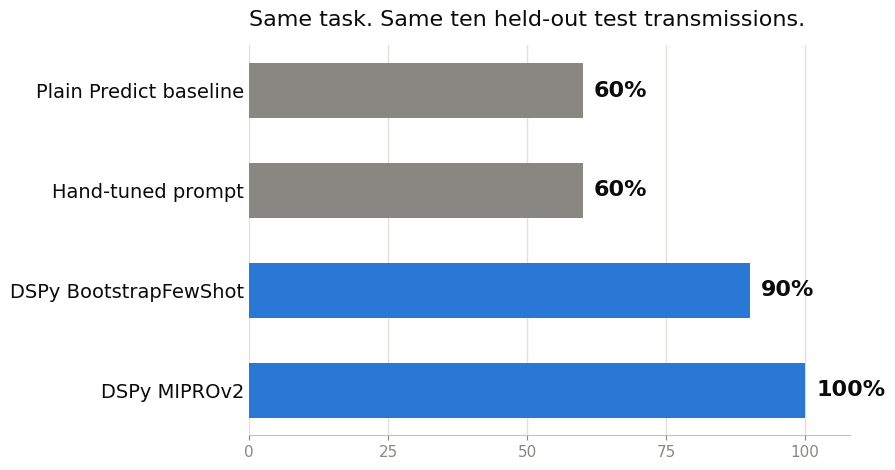

In [17]:
entries = [
    ("Plain Predict baseline", baseline_accuracy),
    ("Hand-tuned prompt", hand_tuned_accuracy),
    ("DSPy BootstrapFewShot", optimized_accuracy),
]
if miprov2_accuracy is not None:
    entries.append(("DSPy MIPROv2", miprov2_accuracy))

try:
    import matplotlib.pyplot as plt

    INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
    CROP_DUSTER, STARSHIP = "#898781", "#2a78d6"
    labels = [name for name, _ in entries]
    values = [acc * 100 for _, acc in entries]
    colors = [STARSHIP if name.startswith("DSPy") else CROP_DUSTER for name in labels]

    fig, ax = plt.subplots(figsize=(9, 0.9 * len(entries) + 1.2))
    bars = ax.barh(labels, values, color=colors, height=0.55)
    ax.invert_yaxis()
    ax.set_xlim(0, 108)
    for bar, v in zip(bars, values):
        ax.text(v + 2, bar.get_y() + bar.get_height() / 2, f"{v:.0f}%",
                va="center", fontsize=16, fontweight="bold", color=INK)
    ax.set_title("Same task. Same ten held-out test transmissions.",
                 fontsize=16, color=INK, loc="left", pad=14)
    ax.tick_params(axis="y", labelsize=14, colors=INK, length=0)
    ax.tick_params(axis="x", labelsize=11, colors=MUTED)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.xaxis.grid(True, color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    plt.tight_layout()
    plt.show()
except ImportError:
    # Text fallback for take-home users who skipped matplotlib
    for name, acc in entries:
        print(f"{name:24s} {'#' * int(acc * 20):20s} {acc*100:.0f}%")

## The method: your Monday-morning workflow

Everything you saw, as eight repeatable steps:

1. **Declare**: write the signature. Inputs and outputs, and that's it.
2. **Compose**: pick a module. `Predict`, `ChainOfThought`, or `ReAct`. Combine several inside a `dspy.Module` if the task has multiple steps.
3. **Collect**: gather 5 to 20 examples of input paired with the right output.
4. **Measure**: write a metric function that returns `True`/`False` or a score from 0 to 1.
5. **Optimize**: `BootstrapFewShot` when you want speed, `MIPROv2` when you want thoroughness.
6. **Verify**: measure accuracy on held-out test examples the optimizer never saw.
7. **Save**: `program.save("artifact.json")`, then `program.load(...)` in production.
8. **Iterate**: when a new model ships, re-point the model string and re-run the optimizer. Do not rewrite prompts.

The full write-up is in `METHOD.md` in the repo.

## Mission complete

- The repo: `github.com/ahliana/dspy_starship`
- The x-ray glasses: `dspy.inspect_history()`. Use them constantly while you learn.
- Switch models any time by changing `FAST_MODEL` or `BIG_MODEL` at the top. Nothing else changes.

Continue on the PyHou Discord, and find your crew on LinkedIn.

What could **you** teach in five minutes? That's a lightning talk. Four minutes plus one for questions. Sign up at the door.